In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action="ignore")

Read the data

In [2]:
df = pd.read_csv("DM1_games_clean.csv")

In [3]:
df

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21920,3233,Ballast,variation game quotpick sticksquot wooden cyli...,1998,1.0000,1.2096,2,4,8.0,11.0,...,21926,0,0,0,0,0,0,0,0,Low
21921,13359,Leapfrog,leapfrog fun family game simple young gamer pl...,2004,1.5000,1.7219,1,6,6.0,361.0,...,21926,0,0,0,0,0,0,0,0,Medium
21922,3295,Athos,monk climb athos mountain reach monastery move...,1993,1.6667,1.7946,2,4,11.0,431.0,...,21926,0,0,0,0,0,0,0,0,Low
21923,176524,Hoplomachus: Origins,hoplomachu origin take story begin small battl...,2015,3.0370,3.2921,1,2,13.8,322.0,...,21926,0,1,0,0,0,0,0,0,High


In [4]:
df.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase',
       'GoodPlayers', 'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes',
       'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted', 'ImagePath', 'Rank:strategygames',
       'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs',
       'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames',
       'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS',
       'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')

In [5]:
df = df.drop(
    columns=[
        'BGGId', 'Rank:strategygames', 'Rank:abstracts', 'Rank:familygames',
        'Rank:thematic', 'Rank:cgs', 'Rank:wargames', 'Rank:partygames',
        'Rank:childrensgames', 'Cat:Thematic', 'Cat:Strategy', 'Cat:War',
        'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens'
    ],
    errors="ignore"
)


In [6]:
df.columns

Index(['Name', 'Description', 'YearPublished', 'GameWeight', 'ComWeight',
       'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'GoodPlayers',
       'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes', 'ComMinPlaytime',
       'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumAlternates',
       'NumExpansions', 'NumImplementations', 'IsReimplementation',
       'Kickstarted', 'ImagePath', 'Rating'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                21925 non-null  object 
 1   Description         21925 non-null  object 
 2   YearPublished       21925 non-null  int64  
 3   GameWeight          21925 non-null  float64
 4   ComWeight           21925 non-null  float64
 5   MinPlayers          21925 non-null  int64  
 6   MaxPlayers          21925 non-null  int64  
 7   ComAgeRec           21925 non-null  float64
 8   LanguageEase        21925 non-null  float64
 9   GoodPlayers         21925 non-null  object 
 10  NumOwned            21925 non-null  int64  
 11  NumWant             21925 non-null  int64  
 12  NumWish             21925 non-null  int64  
 13  NumWeightVotes      21925 non-null  int64  
 14  ComMinPlaytime      21925 non-null  int64  
 15  ComMaxPlaytime      21925 non-null  int64  
 16  MfgA

In [8]:
df.head()


,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,GoodPlayers,...,ComMaxPlaytime,MfgAgeRec,NumUserRatings,NumAlternates,NumExpansions,NumImplementations,IsReimplementation,Kickstarted,ImagePath,Rating
0,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,[],...,30,15,164,0,1,0,0,0,https://cf.geekdo-images.com/KODsRK0MYHHOMjcwp...,Low
1,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,[],...,20,8,38,1,0,0,0,0,https://cf.geekdo-images.com/qVKpawhjdPtv3mvcE...,Medium
2,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,10.0,138.0,[],...,150,12,231,0,1,0,0,0,https://cf.geekdo-images.com/ip7NI05tygaMvaV1a...,High
3,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,138.0,[],...,20,10,81,0,0,0,0,0,https://cf.geekdo-images.com/K5ga4Gs_XAExVXP6z...,Low
4,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,10.0,7.0,[],...,20,8,79,3,0,0,0,0,https://cf.geekdo-images.com/d5DWiG0N2augdAOYX...,Medium


In [9]:
df.tail()

,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,GoodPlayers,...,ComMaxPlaytime,MfgAgeRec,NumUserRatings,NumAlternates,NumExpansions,NumImplementations,IsReimplementation,Kickstarted,ImagePath,Rating
21920,Ballast,variation game quotpick sticksquot wooden cyli...,1998,1.0000,1.2096,2,4,8.0,11.0,[],...,15,6,43,0,0,0,0,0,https://cf.geekdo-images.com/xlM8vP8QfEwYlikYl...,Low
21921,Leapfrog,leapfrog fun family game simple young gamer pl...,2004,1.5000,1.7219,1,6,6.0,361.0,[],...,20,7,184,2,0,0,0,0,https://cf.geekdo-images.com/CpLP33V0HVZzXHJwL...,Medium
21922,Athos,monk climb athos mountain reach monastery move...,1993,1.6667,1.7946,2,4,11.0,431.0,[],...,45,12,74,0,0,0,0,0,https://cf.geekdo-images.com/dX-2Eou2-kknpohRP...,Low
21923,Hoplomachus: Origins,hoplomachu origin take story begin small battl...,2015,3.0370,3.2921,1,2,13.8,322.0,[],...,30,12,573,0,11,0,0,1,https://cf.geekdo-images.com/0zeQ3BCNjO1FxIZEC...,High
21924,Rubout,rulesquotthe goal rubout player cash hand pl...,1989,1.7692,1.9113,2,8,12.0,1199.0,[],...,180,8,66,0,0,0,0,0,https://cf.geekdo-images.com/SY_iYzGekOyGrW0Zo...,Low


In [10]:
df.shape

(21925, 25)

In [11]:
df['Rating'].value_counts()

,count
Rating,
Medium,9644
Low,7245
High,5036


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                21925 non-null  object 
 1   Description         21925 non-null  object 
 2   YearPublished       21925 non-null  int64  
 3   GameWeight          21925 non-null  float64
 4   ComWeight           21925 non-null  float64
 5   MinPlayers          21925 non-null  int64  
 6   MaxPlayers          21925 non-null  int64  
 7   ComAgeRec           21925 non-null  float64
 8   LanguageEase        21925 non-null  float64
 9   GoodPlayers         21925 non-null  object 
 10  NumOwned            21925 non-null  int64  
 11  NumWant             21925 non-null  int64  
 12  NumWish             21925 non-null  int64  
 13  NumWeightVotes      21925 non-null  int64  
 14  ComMinPlaytime      21925 non-null  int64  
 15  ComMaxPlaytime      21925 non-null  int64  
 16  MfgA

In [13]:
def data_review(df):

    # shape of data
    print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns . \n")

    # check about missing values
    print("\n" + 10 * "-" + "Missing Values".center(20) + 10 * "-"+"\n")
    print(df.isna().sum()/len(df))
    print(f"\nthe number of all missing values in data equal : { df.isna().sum().sum()}")

    # check about duplicated rows
    print(f"\nthere are {df.duplicated().sum()} duplicated rows")

In [14]:
data_review(df)

Dataset has 21925 rows and 25 columns . 


----------   Missing Values   ----------

Name                  0.0
Description           0.0
YearPublished         0.0
GameWeight            0.0
ComWeight             0.0
MinPlayers            0.0
MaxPlayers            0.0
ComAgeRec             0.0
LanguageEase          0.0
GoodPlayers           0.0
NumOwned              0.0
NumWant               0.0
NumWish               0.0
NumWeightVotes        0.0
ComMinPlaytime        0.0
ComMaxPlaytime        0.0
MfgAgeRec             0.0
NumUserRatings        0.0
NumAlternates         0.0
NumExpansions         0.0
NumImplementations    0.0
IsReimplementation    0.0
Kickstarted           0.0
ImagePath             0.0
Rating                0.0
dtype: float64

the number of all missing values in data equal : 0

there are 0 duplicated rows


In [15]:
print("The Number of Null in DataFrame is: ",df.isnull().sum().sum())
print("The Number of NAN in DataFrame is: ",df.isna().sum().sum())
print("The Number of duplicated in DataFrame is: ",df.duplicated().sum().sum())

The Number of Null in DataFrame is:  0
The Number of NAN in DataFrame is:  0
The Number of duplicated in DataFrame is:  0


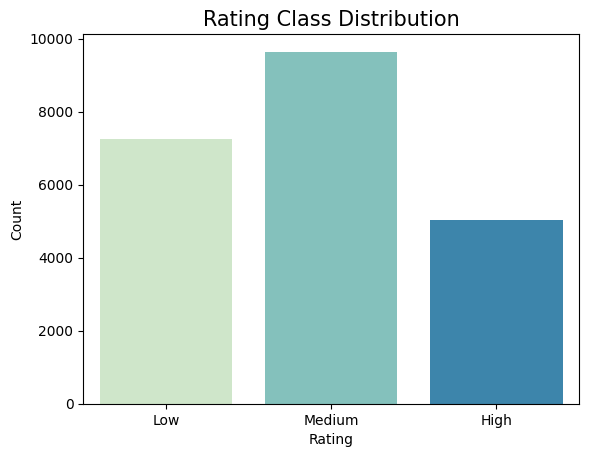

In [16]:
sns.countplot(data=df, x='Rating', palette='GnBu')
plt.title("Rating Class Distribution", fontsize=15)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


correlation Matrix

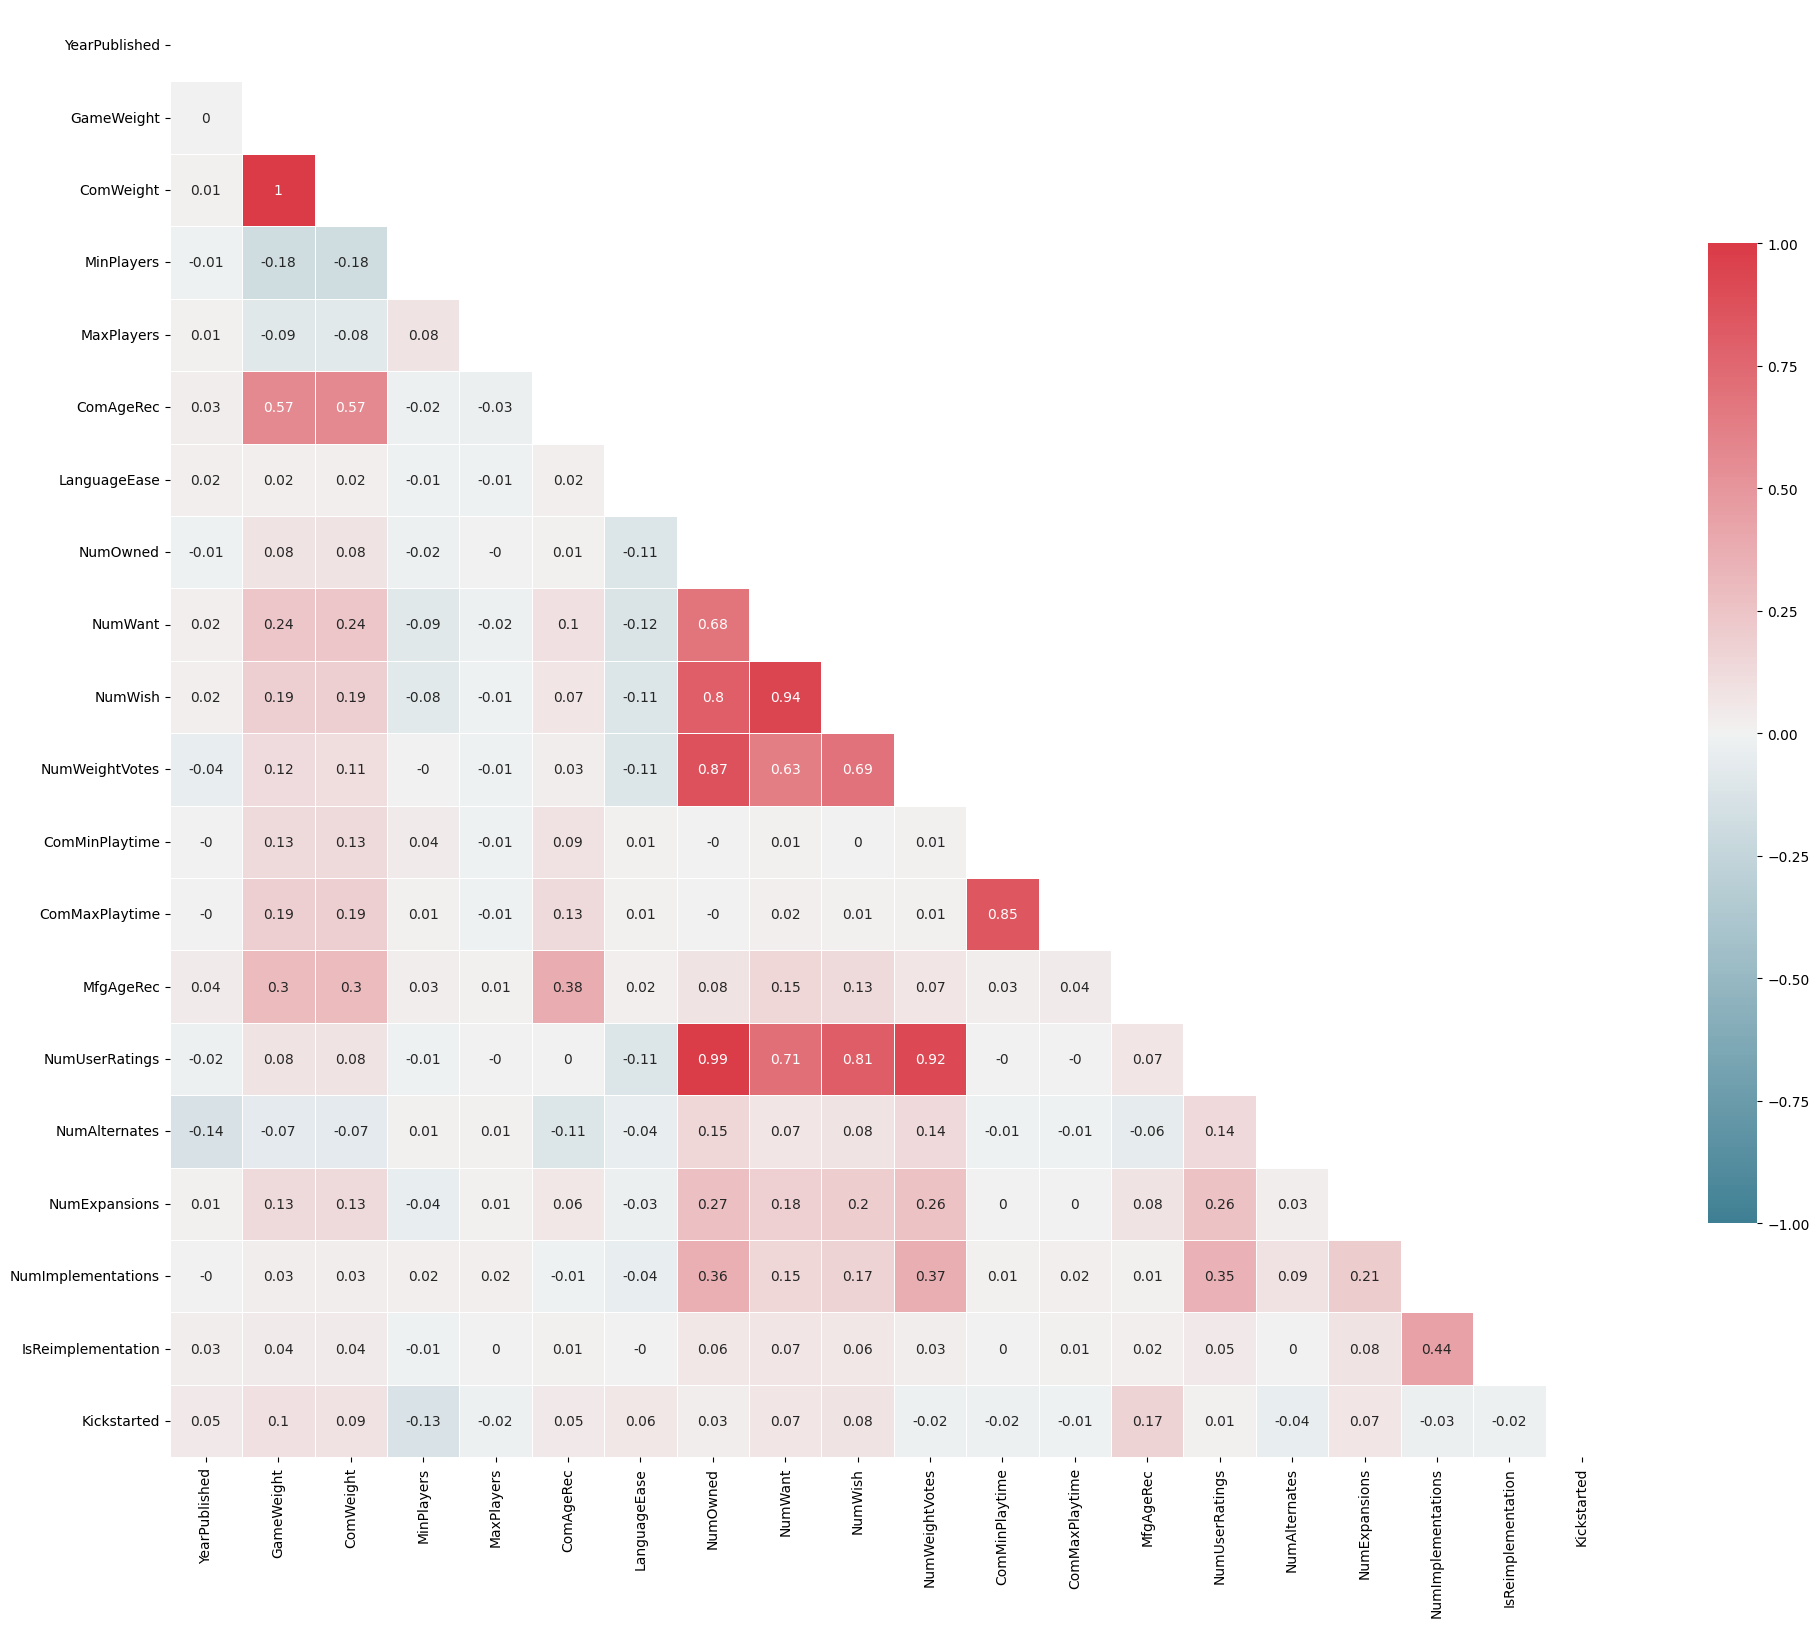

In [17]:
import numpy as np

# Generate and visualize the correlation matrix
corr = df.select_dtypes(include=['number']).corr().round(2)

# Mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set figure size
f, ax = plt.subplots(figsize=(20, 20))

# Define custom colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.tight_layout()

heatmap

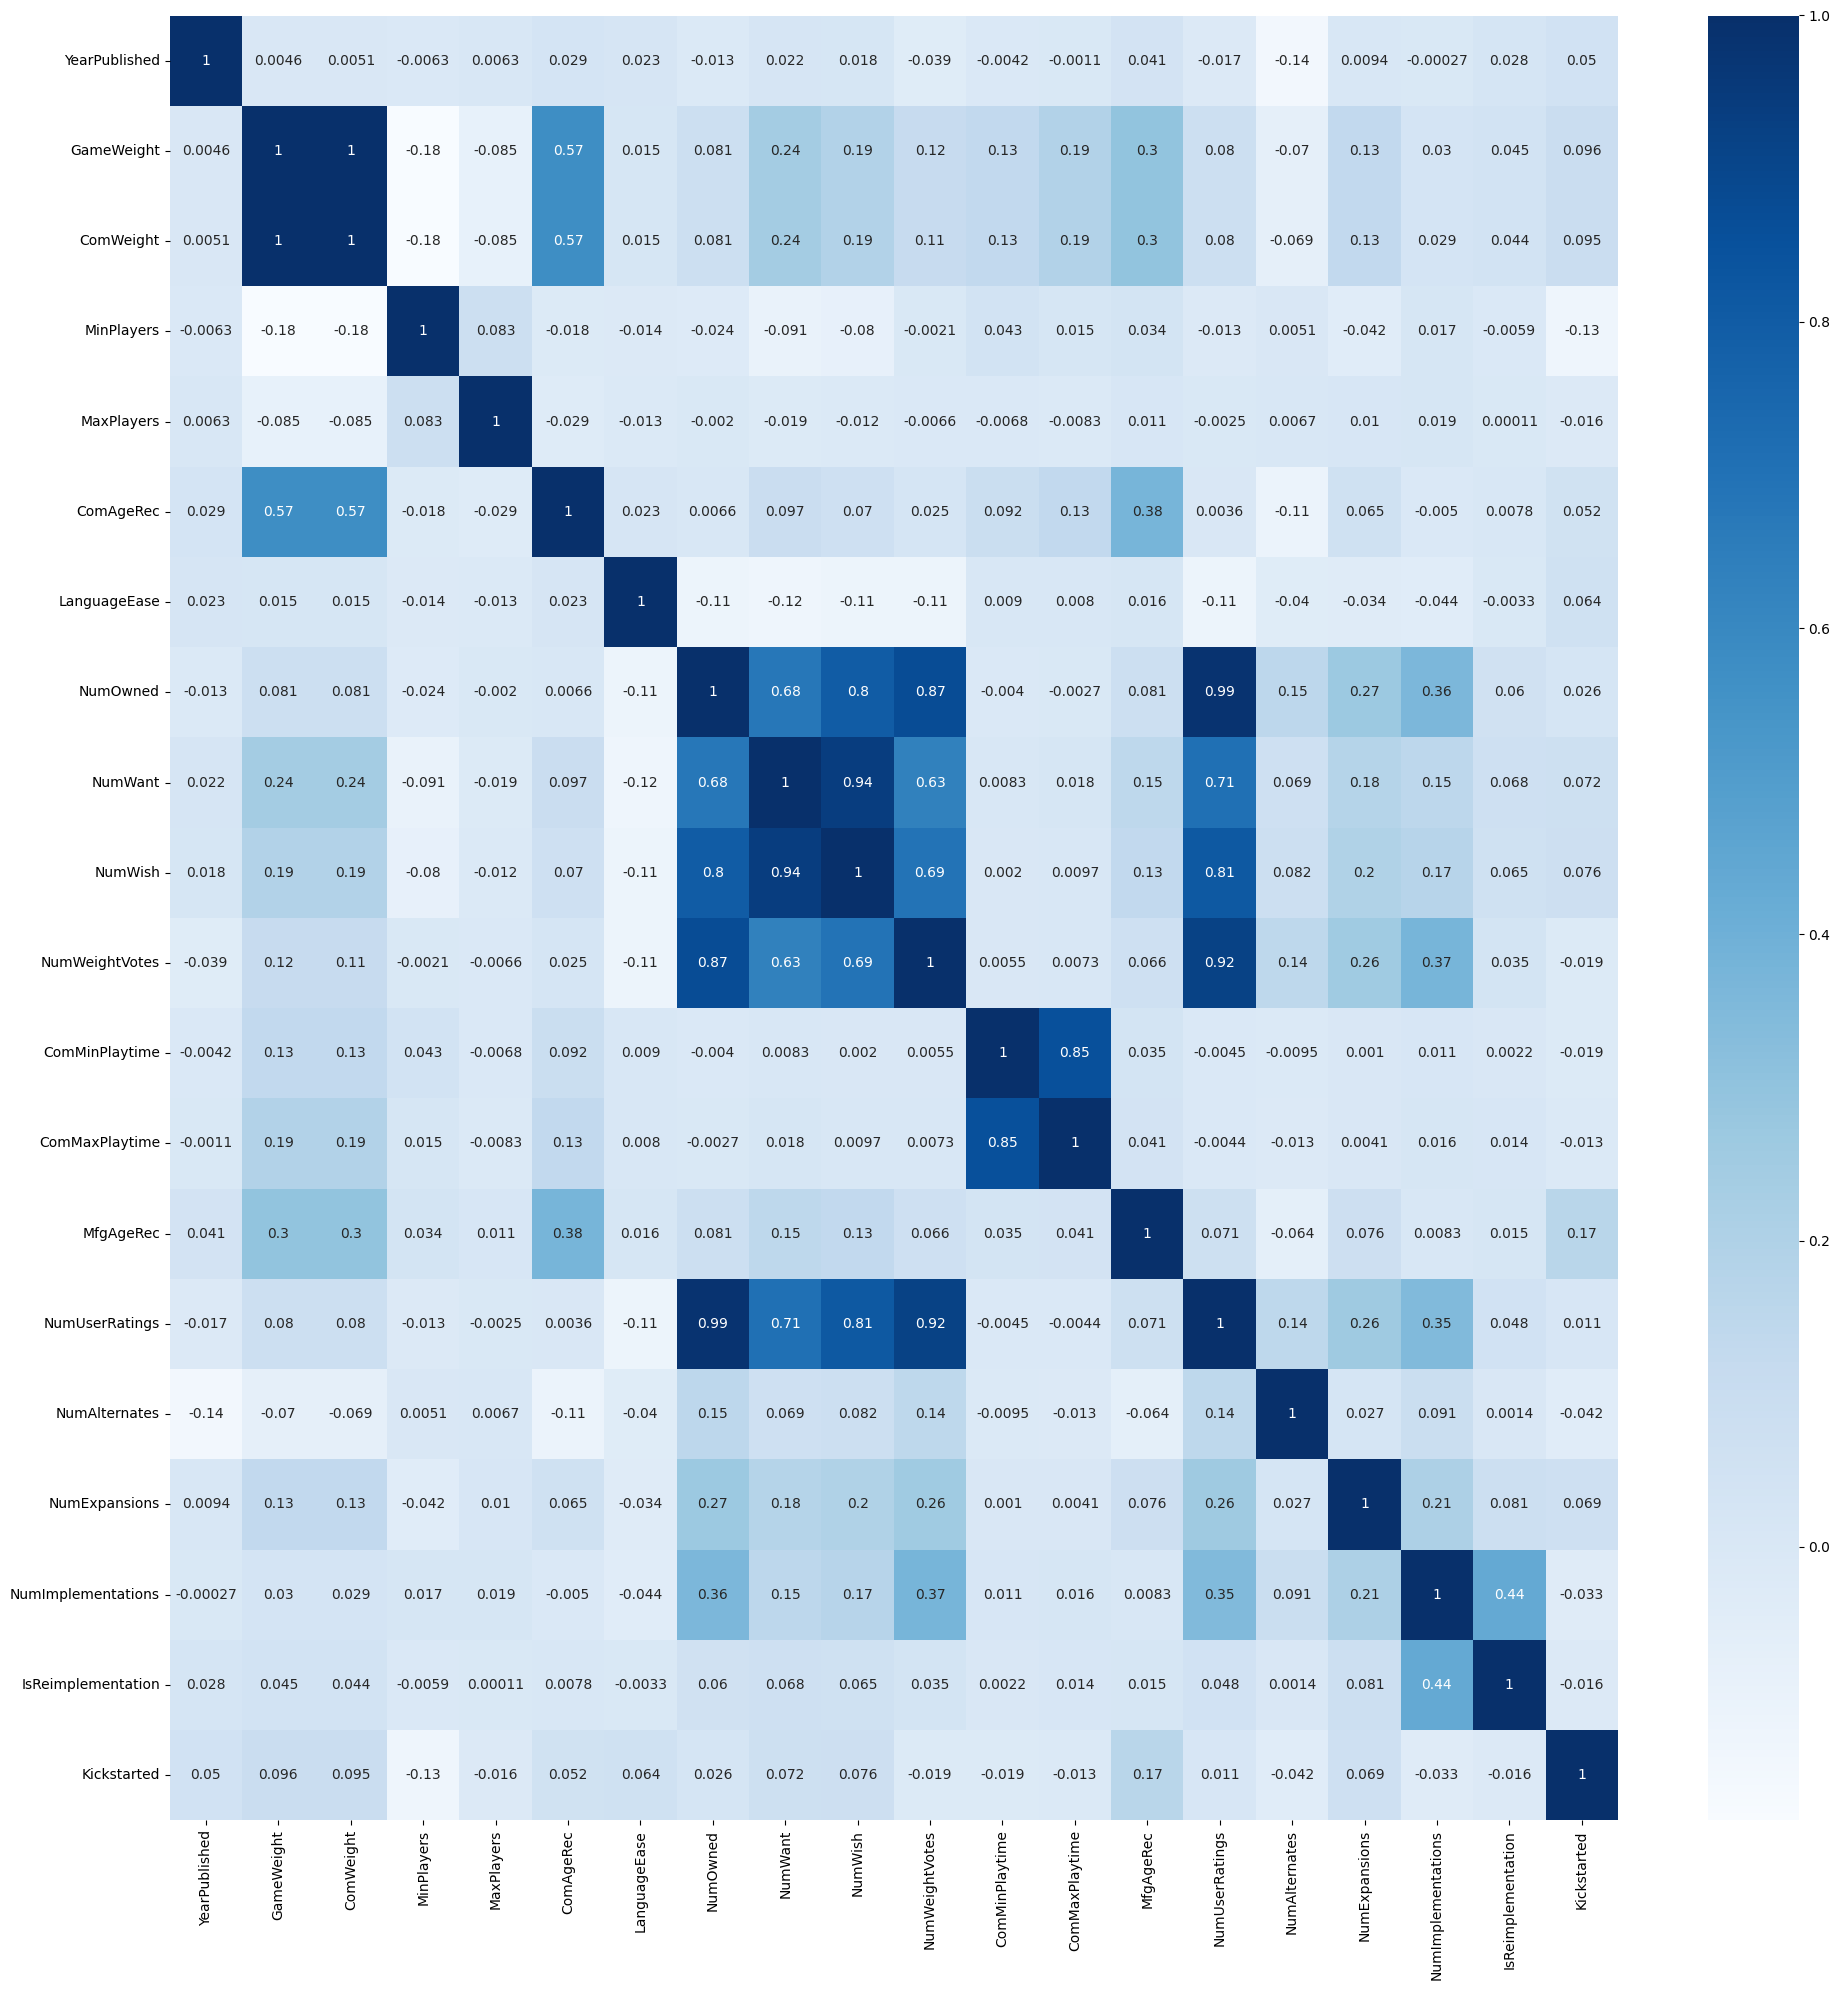

In [18]:
plt.figure(figsize=(20,20))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='Blues', annot=True)
plt.tight_layout()

let's plot the encoded version:

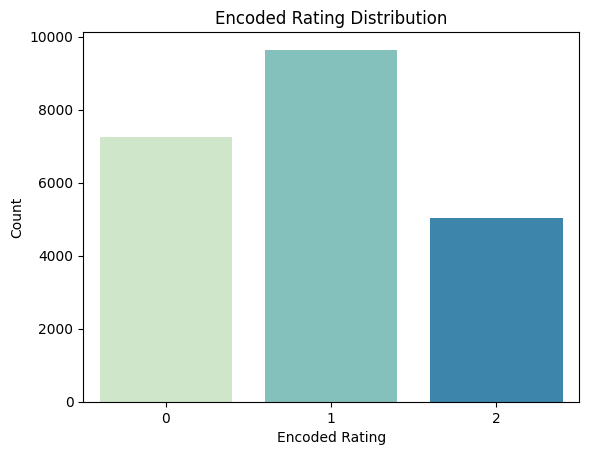

In [19]:
rating_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Rating_encoded'] = df['Rating'].map(rating_mapping)
sns.countplot(data=df, x='Rating_encoded', palette='GnBu')
plt.title("Encoded Rating Distribution")
plt.xlabel("Encoded Rating")
plt.ylabel("Count")
plt.show()

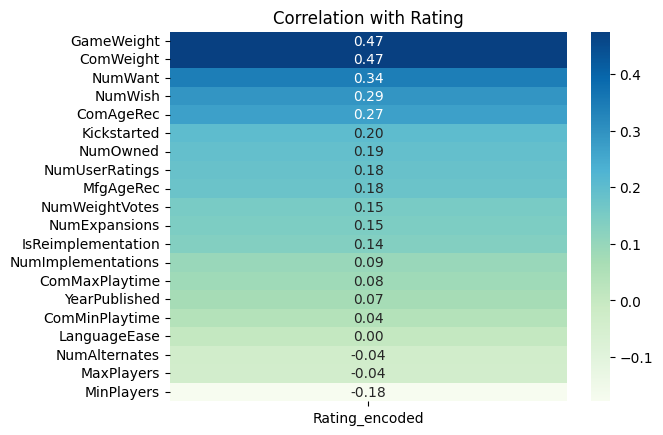

In [20]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

corr = df_numeric.corr()

target_corr = corr['Rating_encoded'].drop('Rating_encoded')
target_corr_sorted = target_corr.sort_values(ascending=False)

sns.heatmap(target_corr_sorted.to_frame(), cmap="GnBu", annot=True, fmt='.2f')
plt.title('Correlation with Rating')
plt.show()


In [21]:
X = df.drop(columns=['Rating', 'Rating_encoded'])
y = df['Rating_encoded']


spliting

In [22]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

test_size=0.30: This means 30% of the data will be used for testing, while the remaining 70% will be used for training.

random_state=1: This sets a seed for random number generation to ensure that the split is reproducible every time you run the cod

scaler:

In [23]:
import numpy as np
# Ensure X contains only numerical columns and y is the encoded target
X = df.select_dtypes(include=np.number).drop(columns=['Rating_encoded'])
y = df['Rating_encoded']

# Re-perform train-test split with the corrected X and y
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Feature Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

elbow method

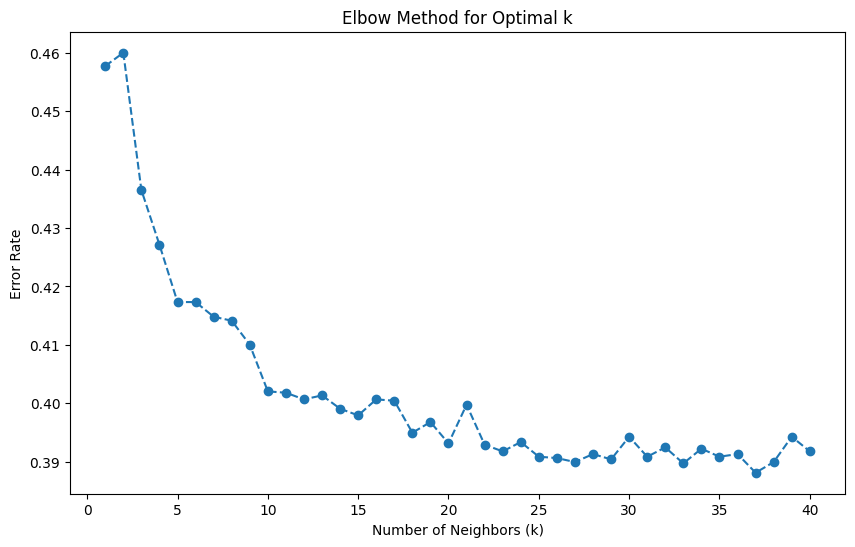

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Apply the Elbow method
error_rates = []
k_values = range(1, 41)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    error = 1 - accuracy_score(y_test, y_pred)
    error_rates.append(error)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate')
plt.show()

In [36]:
knn = KNeighborsClassifier(n_neighbors=21)

knn.fit(x_train, y_train)
pred = knn.predict(x_test)

print('WITH K=21')
print('\n')
print(confusion_matrix(y_test, pred))
print('\n')
print(classification_report(y_test, pred))

WITH K=21


[[ 439  899   85]
 [ 576 1254   87]
 [ 292  710   43]]


              precision    recall  f1-score   support

           0       0.34      0.31      0.32      1423
           1       0.44      0.65      0.52      1917
           2       0.20      0.04      0.07      1045

    accuracy                           0.40      4385
   macro avg       0.32      0.33      0.30      4385
weighted avg       0.35      0.40      0.35      4385



Cross validation

Optimal k using 5-fold cross-validation: 23


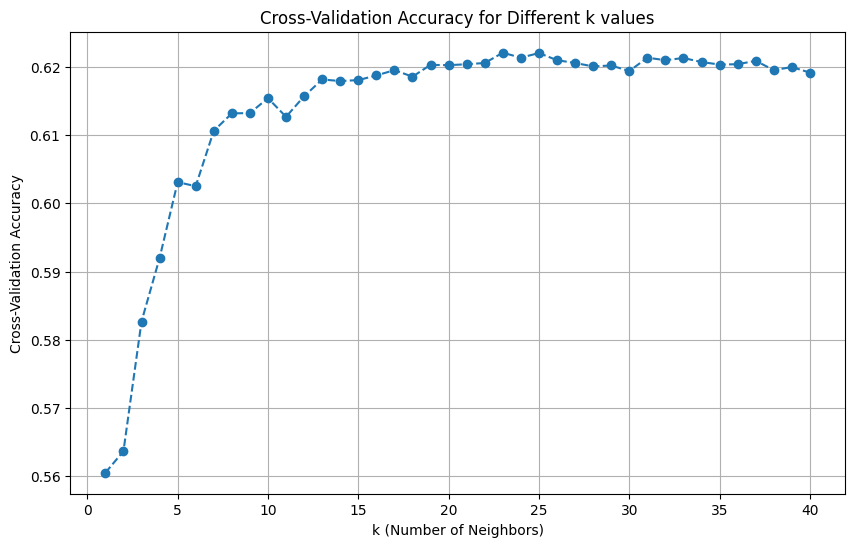

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Range of k values to test
k_values = range(1, 41)
cv_scores = []

# Perform 5-fold cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find the k with the highest average accuracy
optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal k using 5-fold cross-validation: {optimal_k}")

# Optional: Plot CV accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Cross-Validation Accuracy for Different k values")
plt.grid(True)
plt.show()

GridSearch

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid
param_grid = {'n_neighbors': range(1, 41)}

# Initialize the KNN model
knn = KNeighborsClassifier()

# Perform GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

# Output the best parameter and score
print(f"Best k using GridSearchCV: {grid_search.best_params_['n_neighbors']}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")

Best k using GridSearchCV: 23
Best cross-validation accuracy: 0.6220752565564424


randomizedsearchCv

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Define the parameter grid for k values
param_grid = {
    'n_neighbors': np.arange(1, 40)   # search k = 1 to 39
}

# Initialize base KNN model
knn = KNeighborsClassifier()

# Perform RandomizedSearchCV with 5-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_grid,
    n_iter=5,               # number of random samples to test
    cv=5,                   # 5-fold cross-validation
    scoring='accuracy',
    random_state=42
)

# Fit the search on the entire dataset
random_search.fit(X, y)

# Output the best results
print(f"Best k using RandomizedSearchCV: {random_search.best_params_['n_neighbors']}")
print("Best cross-validation accuracy: {}".format(random_search.best_score_))

Best k using RandomizedSearchCV: 31
Best cross-validation accuracy: 0.621345496009122


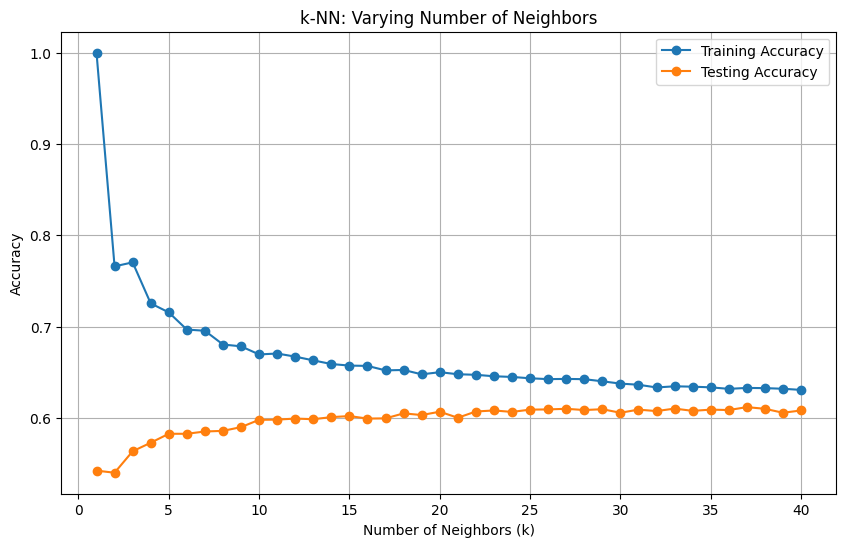

In [28]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

# Array of k values to test
neighbors = np.arange(1, 41)

# Arrays to store training and testing accuracy
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

# Loop over k values
for i, k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)

    # Fit the model
    knn.fit(x_train_scaled, y_train)

    # Compute accuracy on training set
    train_accuracy[i] = knn.score(x_train_scaled, y_train)

    # Compute accuracy on test set
    test_accuracy[i] = knn.score(x_test_scaled, y_test)

# Plot both training and testing accuracy
plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy', marker='o')

plt.title('k-NN: Varying Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Summary of k-NN Hyperparameter Tuning Results:

Elbow Method and crossvalidation and GridSearchCV suggest a k = 23, and randomizedcv suggest k = 31.
Conclusion, testing both values on a validation set is recommended to finalize the optimal k.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Function to evaluate k-NN models
def evaluate_knn(k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    return accuracy_score(y_val, y_pred)

# Test k = 23 and k = 31
accuracy_k23 = evaluate_knn(23)
accuracy_k31 = evaluate_knn(31)

print(f'Accuracy for k = 23: {accuracy_k23:.4f}')
print(f'Accuracy for k = 31: {accuracy_k31:.4f}')


Accuracy for k = 23: 0.6157
Accuracy for k = 31: 0.6223


with k = 23

In [30]:
knn = KNeighborsClassifier(n_neighbors=23)

# Fit the KNN model

knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=23)

In [31]:
y_pred_knn = knn.predict(x_test_scaled)

In [32]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Re-initialize and fit the KNN model for k=23 (ensuring it's fitted for this cell)
knn = KNeighborsClassifier(n_neighbors=23)
knn.fit(x_train_scaled, y_train)

# Make predictions with the fitted model
y_pred_knn = knn.predict(x_test_scaled)

print("KNN Model Evaluation\n")

# Training accuracy
train_accuracy = accuracy_score(y_train, knn.predict(x_train_scaled)) * 100
print("Accuracy on Training Set: {:.4f} %".format(train_accuracy))

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred_knn) * 100 # Use y_pred_knn
print("Accuracy on Test Set: {:.4f} %".format(test_accuracy))


# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn)) # Use y_pred_knn


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn)) # Use y_pred_knn

KNN Model Evaluation

Accuracy on Training Set: 46.9840 %
Accuracy on Test Set: 40.3877 %

Confusion Matrix:
[[ 423  937   63]
 [ 538 1294   85]
 [ 283  708   54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.30      0.32      1423
           1       0.44      0.68      0.53      1917
           2       0.27      0.05      0.09      1045

    accuracy                           0.40      4385
   macro avg       0.35      0.34      0.31      4385
weighted avg       0.37      0.40      0.36      4385



with k = 31

In [33]:
knn = KNeighborsClassifier(n_neighbors=31)

# Fit the KNN model

knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=31)

In [34]:
y_pred_knn = knn.predict(x_test_scaled)

In [35]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Re-initialize and fit the KNN model for k=31 (ensuring it's fitted for this cell)
knn = KNeighborsClassifier(n_neighbors=31)
knn.fit(x_train_scaled, y_train)

# Make predictions with the fitted model
y_pred_knn = knn.predict(x_test_scaled)

print("KNN Model Evaluation\n")

# Training accuracy
train_accuracy = accuracy_score(y_train, knn.predict(x_train_scaled)) * 100
print("Accuracy on Training Set: {:.4f} %".format(train_accuracy))

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred_knn) * 100 # Use y_pred_knn
print("Accuracy on Test Set: {:.4f} %".format(test_accuracy))


# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn)) # Use y_pred_knn


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn)) # Use y_pred_knn

KNN Model Evaluation

Accuracy on Training Set: 46.4139 %
Accuracy on Test Set: 40.7754 %

Confusion Matrix:
[[ 362 1014   47]
 [ 465 1381   71]
 [ 254  746   45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.25      0.29      1423
           1       0.44      0.72      0.55      1917
           2       0.28      0.04      0.07      1045

    accuracy                           0.41      4385
   macro avg       0.35      0.34      0.30      4385
weighted avg       0.37      0.41      0.35      4385

